In [1]:
import random
import json
import re
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.metrics import edit_distance

from transformers import AutoTokenizer
import pickle

from pathlib import Path

WORK_DIR = Path().cwd().parent

random.seed(6)
np.random.seed(6)


Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


# Experiment 6 - MCQ Long answer HTML tags

For this experiment I changed the system prompt, asking the LLM to generate more text (about "thinking") and then give the final answer.


**Parameters:**
- model: llama3.1:8b
- system prompt: MCQ_system_prompt_v3.txt
- temperature: 0.1
- sampling method: (default) top-p (p=0.9)
- the output is limited to 128 tokens (shouldn't influence the results, it only cutoffs the generation)


Let's load the ground truth from the `STAR_QA_question_and_stsg_val.json` file where we extracted QA and spatio-temporal scene graphs

In [2]:
ground_truth = []

with open('../data/datasets/STAR_QA_and_stsg_val.json') as f:
    data = json.load(f)
    ground_truth = [{
        'id': sample['question_id'],
        'choices': sample['choices'],
        'num': sample['answer'],
        'text': sample['choices'][str(sample['answer'])]
    } for sample in data]


# we keep num as str so we can directrly access choices dictionaries
gt_df = pd.DataFrame(ground_truth).astype({'id': 'string', 'num': 'string', 'text': 'string'})
gt_df.set_index('id', inplace=True)
gt_df


,choices,num,text
id,,,
Interaction_T1_13,"{'0': 'The closet/cabinet.', '1': 'The blanket...",2,The clothes.
Interaction_T1_14,"{'0': 'The blanket.', '1': 'The table.', '2': ...",2,The clothes.
Interaction_T1_31,"{'0': 'The pillow.', '1': 'The bag.', '2': 'Th...",2,The clothes.
Interaction_T1_32,"{'0': 'The food.', '1': 'The shoe.', '2': 'The...",1,The shoe.
Interaction_T1_40,"{'0': 'The broom.', '1': 'The closet/cabinet.'...",1,The closet/cabinet.
...,...,...,...
Feasibility_T6_1453,"{'0': 'Wash the table.', '1': 'Take the box.',...",0,Wash the table.
Feasibility_T6_1454,"{'0': 'Take the towel.', '1': 'Throw the bag.'...",0,Take the towel.
Feasibility_T6_1455,"{'0': 'Throw the bag.', '1': 'Wash the table.'...",1,Wash the table.


In [3]:
models_pred = {}
html_tags_pattern = r'<Final answer>\s*A:\s*\d\.\s*((?:\w+(?:\s|\/)?){,10}\.)\s*</Final answer>'
ans_regex_pattern = r'A:\s*(?:\d\.)?\s*((?:\w+(?:\s|\/)?){,10}\.)'


## Llama3.2-3b

In [4]:
# needed to modify the output file because of the bug
# I introduced in the code
predictions = []
with open('../outputs/mcq_reasoning_llama3.2_20250210_20:17:23.jsonl') as f:
    predictions = [json.loads(line) for line in f.readlines()]

# transforming the id key from `qid` to `id` for consistency and `response` to `answer`
predictions_df = pd.DataFrame(predictions, dtype='string').rename(columns={'qid':'id', 'response':'answer'})
predictions_df.set_index('id', inplace=True)
predictions_df


,answer
id,
Interaction_T1_13,<Reasoning> To determine which object was tidi...
Interaction_T1_14,<Reasoning> To determine which object was tidi...
Interaction_T1_31,Error while generating the response. Look at t...
Interaction_T1_32,<Reasoning> To determine which object was put ...
Interaction_T1_40,<Reasoning> The question asks which object was...
...,...
Feasibility_T6_1453,<Reasoning> To determine what the person is ab...
Feasibility_T6_1454,"<Reasoning> To answer this question, we need t..."
Feasibility_T6_1455,"<Reasoning> To answer this question, we need t..."


In [5]:
predictions_df.shape


(7098, 1)

In [6]:
# Check if the the template is somewhere in the answer
predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


print(f"Answer following the template: {predictions_df['html_tags_mask'].value_counts()[True]}\n"
      f"{predictions_df['html_tags_mask'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['html_tags_mask'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")


Answer following the template: 2100
29.59% of the total

Only 4998 samples do not contain the answer in the response with the specified format


/tmp/ipykernel_1384549/3440733018.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


Let's start by viewing how many answers follow the template:

In [7]:
# Check if the the template is somewhere in the answer
#
# An example of the template expressed by the regex is: A: 1. The answer.
# where the number followed by a dot is optional
predictions_df['contains_answer'] = (
      predictions_df['answer']
      .apply(lambda x: True if re.search(ans_regex_pattern, x) else False)
)

print(f"Answer following the template: {predictions_df['contains_answer'] .value_counts()[True]}\n"
      f"{predictions_df['contains_answer'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['contains_answer'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")

predictions_df["pred_text"] = ""
# Use .loc to safely modify the original DataFrame
mask = predictions_df['contains_answer']
predictions_df.loc[mask, 'pred_text'] = (
      predictions_df.loc[mask, 'answer']
      .apply(lambda x: re.findall(ans_regex_pattern, x)[-1])
)
predictions_df['pred_text'] = (
      predictions_df['pred_text']
      .str.strip()
      .apply(lambda x: x + '.' if x and x[-1] != '.' else x)
)

predictions_df 

Answer following the template: 6900
97.21% of the total

Only 198 samples do not contain the answer in the response with the specified format


,answer,html_tags_mask,contains_answer,pred_text
id,,,,
Interaction_T1_13,<Reasoning> To determine which object was tidi...,True,True,The clothes.
Interaction_T1_14,<Reasoning> To determine which object was tidi...,False,True,The clothes.
Interaction_T1_31,Error while generating the response. Look at t...,False,False,
Interaction_T1_32,<Reasoning> To determine which object was put ...,False,True,The shoe.
Interaction_T1_40,<Reasoning> The question asks which object was...,False,True,The blanket.
...,...,...,...,...
Feasibility_T6_1453,<Reasoning> To determine what the person is ab...,True,True,Wash the table.
Feasibility_T6_1454,"<Reasoning> To answer this question, we need t...",False,True,Wipe the table.
Feasibility_T6_1455,"<Reasoning> To answer this question, we need t...",True,True,Take the shoe.


In [8]:
# Check that contains answer is subset of html_tags
assert (predictions_df['html_tags_mask'] & predictions_df['contains_answer'] ).sum() == predictions_df['html_tags_mask'].sum()


In [9]:
models_pred["Llama3.2:3B"] = predictions_df


## Llama3.1-8b

In [10]:
# needed to modify the output file because of the bug
# I introduced in the code
predictions = []
with open('../outputs/responses_llama3.1:8b_20250219_13:49:44.jsonl') as f:
    predictions = [json.loads(line) for line in f.readlines()]

# transforming the id key from `qid` to `id` for consistency and `response` to `answer`
predictions_df = pd.DataFrame(predictions, dtype='string').rename(columns={'qid':'id', 'response':'answer'})
predictions_df.set_index('id', inplace=True)
predictions_df


,answer
id,
Interaction_T1_13,<Reasoning> To determine which object was tidi...
Interaction_T1_14,<Reasoning> To determine which object was tidi...
Interaction_T1_31,<Reasoning> To determine which object was thro...
Interaction_T1_32,<Reasoning> To determine which object was put ...
Interaction_T1_40,<Reasoning> The question asks which object was...
...,...
Feasibility_T6_1453,<Reasoning> The person is initially seen holdi...
Feasibility_T6_1454,<Reasoning> The person is initially standing i...
Feasibility_T6_1455,<Reasoning> The person is initially standing i...


In [11]:
predictions_df.shape


(7098, 1)

In [12]:
# Check if the the template is somewhere in the answer
predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


print(f"Answer following the template: {predictions_df['html_tags_mask'] .value_counts()[True]}\n"
      f"{predictions_df['html_tags_mask'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['html_tags_mask'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")


Answer following the template: 5038
70.98% of the total

Only 2060 samples do not contain the answer in the response with the specified format


/tmp/ipykernel_1384549/3888682698.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


Let's start by viewing how many answers follow the template:

In [13]:
# Check if the the template is somewhere in the answer
#
# An example of the template expressed by the regex is: A: 1. The answer.
# where the number followed by a dot is optional
predictions_df['contains_answer'] = (
      predictions_df['answer']
      .apply(lambda x: True if re.search(ans_regex_pattern, x) else False)
)

print(f"Answer following the template: {predictions_df['contains_answer'] .value_counts()[True]}\n"
      f"{predictions_df['contains_answer'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['contains_answer'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")

predictions_df["pred_text"] = ""
# Use .loc to safely modify the original DataFrame
mask = predictions_df['contains_answer']
predictions_df.loc[mask, 'pred_text'] = (
      predictions_df.loc[mask, 'answer']
      .apply(lambda x: re.findall(ans_regex_pattern, x)[-1])
)
predictions_df['pred_text'] = (
      predictions_df['pred_text']
      .str.strip()
      .apply(lambda x: x + '.' if x and x[-1] != '.' else x)
)

predictions_df 

Answer following the template: 6543
92.18% of the total

Only 555 samples do not contain the answer in the response with the specified format


,answer,html_tags_mask,contains_answer,pred_text
id,,,,
Interaction_T1_13,<Reasoning> To determine which object was tidi...,True,True,The clothes.
Interaction_T1_14,<Reasoning> To determine which object was tidi...,False,True,The clothes.
Interaction_T1_31,<Reasoning> To determine which object was thro...,False,True,The clothes.
Interaction_T1_32,<Reasoning> To determine which object was put ...,True,True,The shoe.
Interaction_T1_40,<Reasoning> The question asks which object was...,True,True,The blanket.
...,...,...,...,...
Feasibility_T6_1453,<Reasoning> The person is initially seen holdi...,True,True,Put down the phone/camera.
Feasibility_T6_1454,<Reasoning> The person is initially standing i...,True,True,Throw the bag.
Feasibility_T6_1455,<Reasoning> The person is initially standing i...,False,True,Wash the table.


In [14]:
# Check that contains answer is subset of html_tags
assert (predictions_df['html_tags_mask'] & predictions_df['contains_answer'] ).sum() == predictions_df['html_tags_mask'].sum()


In [15]:
models_pred["Llama3.1:8B"] = predictions_df


## Deepseek-r1:1.5b

In [16]:
# needed to modify the output file because of the bug
# I introduced in the code
predictions = []
with open('../outputs/responses_deepseek-r1:1.5b_20250218_18:07:17.jsonl') as f:
    predictions = [json.loads(line) for line in f.readlines()]

# transforming the id key from `qid` to `id` for consistency and `response` to `answer`
predictions_df = pd.DataFrame(predictions, dtype='string').rename(columns={'qid':'id', 'response':'answer'})
predictions_df.set_index('id', inplace=True)
predictions_df


,answer
id,
Interaction_T1_13,"<think> Okay, so I'm trying to figure out this..."
Interaction_T1_14,"<think> Alright, let's tackle this question st..."
Interaction_T1_31,"<think> Okay, so I need to figure out which ob..."
Interaction_T1_32,"<think> Okay, so I'm trying to figure out whic..."
Interaction_T1_40,"<think> Okay, so I'm trying to figure out this..."
...,...
Feasibility_T6_1453,"<think> Okay, so I'm trying to figure out what..."
Feasibility_T6_1454,"<think> Alright, let's tackle this question st..."
Feasibility_T6_1455,"<think> Okay, so I need to figure out what the..."


In [17]:
predictions_df.shape


(7098, 1)

In [18]:
# Check if the the template is somewhere in the answer
predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


print(f"Answer following the template: {predictions_df['html_tags_mask'] .value_counts()[True]}\n"
      f"{predictions_df['html_tags_mask'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['html_tags_mask'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")


/tmp/ipykernel_1384549/3888682698.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


Answer following the template: 3700
52.13% of the total

Only 3398 samples do not contain the answer in the response with the specified format


Let's start by viewing how many answers follow the template:

In [19]:
# Check if the the template is somewhere in the answer
#
# An example of the template expressed by the regex is: A: 1. The answer.
# where the number followed by a dot is optional
predictions_df['contains_answer'] = (
      predictions_df['answer']
      .apply(lambda x: True if re.search(ans_regex_pattern, x) else False)
)

print(f"Answer following the template: {predictions_df['contains_answer'] .value_counts()[True]}\n"
      f"{predictions_df['contains_answer'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['contains_answer'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")

predictions_df["pred_text"] = ""
# Use .loc to safely modify the original DataFrame
mask = predictions_df['contains_answer']
predictions_df.loc[mask, 'pred_text'] = (
      predictions_df.loc[mask, 'answer']
      .apply(lambda x: re.findall(ans_regex_pattern, x)[-1])
)
predictions_df['pred_text'] = (
      predictions_df['pred_text']
      .str.strip()
      .apply(lambda x: x + '.' if x and x[-1] != '.' else x)
)

predictions_df 

Answer following the template: 5765
81.22% of the total

Only 1333 samples do not contain the answer in the response with the specified format


,answer,html_tags_mask,contains_answer,pred_text
id,,,,
Interaction_T1_13,"<think> Okay, so I'm trying to figure out this...",True,True,The closet/cabinet.
Interaction_T1_14,"<think> Alright, let's tackle this question st...",False,True,The clothes.
Interaction_T1_31,"<think> Okay, so I need to figure out which ob...",True,True,The clothes.
Interaction_T1_32,"<think> Okay, so I'm trying to figure out whic...",True,True,The shoe.
Interaction_T1_40,"<think> Okay, so I'm trying to figure out this...",False,True,The blanket.
...,...,...,...,...
Feasibility_T6_1453,"<think> Okay, so I'm trying to figure out what...",False,True,Open the bag.
Feasibility_T6_1454,"<think> Alright, let's tackle this question st...",False,True,Hold the towel.
Feasibility_T6_1455,"<think> Okay, so I need to figure out what the...",False,False,


In [20]:
# Check that contains answer is subset of html_tags
assert (predictions_df['html_tags_mask'] & predictions_df['contains_answer'] ).sum() == predictions_df['html_tags_mask'].sum()


In [21]:
models_pred["Deepseek-R1:1.5B"] = predictions_df


## Deepseek-r1:7b

In [22]:
# needed to modify the output file because of the bug
# I introduced in the code
predictions = []
with open('../outputs/responses_deepseek-r1:7b_20250219_13:52:42.jsonl') as f:
    predictions = [json.loads(line) for line in f.readlines()]

# transforming the id key from `qid` to `id` for consistency and `response` to `answer`
predictions_df = pd.DataFrame(predictions, dtype='string').rename(columns={'qid':'id', 'response':'answer'})
predictions_df.set_index('id', inplace=True)
predictions_df


,answer
id,
Interaction_T1_13,"<think> Okay, so I need to figure out which ob..."
Interaction_T1_14,"<think> Okay, so I need to figure out which ob..."
Interaction_T1_31,"<think> Okay, so I need to figure out which ob..."
Interaction_T1_32,"<think> Okay, so I need to figure out which ob..."
Interaction_T1_40,"<think> Okay, so I need to figure out which ob..."
...,...
Feasibility_T6_1453,"<think> Okay, so I'm trying to figure out what..."
Feasibility_T6_1454,"<think> Okay, so I need to figure out what the..."
Feasibility_T6_1455,"<think> Alright, so I'm trying to figure out w..."


In [23]:
predictions_df.shape


(7098, 1)

In [24]:
# Check if the the template is somewhere in the answer
predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


print(f"Answer following the template: {predictions_df['html_tags_mask'] .value_counts()[True]}\n"
      f"{predictions_df['html_tags_mask'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['html_tags_mask'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")


/tmp/ipykernel_1384549/3888682698.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


Answer following the template: 2467
34.76% of the total

Only 4631 samples do not contain the answer in the response with the specified format


Let's start by viewing how many answers follow the template:

In [25]:
# Check if the the template is somewhere in the answer
#
# An example of the template expressed by the regex is: A: 1. The answer.
# where the number followed by a dot is optional
predictions_df['contains_answer'] = (
      predictions_df['answer']
      .apply(lambda x: True if re.search(ans_regex_pattern, x) else False)
)

print(f"Answer following the template: {predictions_df['contains_answer'] .value_counts()[True]}\n"
      f"{predictions_df['contains_answer'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['contains_answer'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")

predictions_df["pred_text"] = ""
# Use .loc to safely modify the original DataFrame
mask = predictions_df['contains_answer']
predictions_df.loc[mask, 'pred_text'] = (
      predictions_df.loc[mask, 'answer']
      .apply(lambda x: re.findall(ans_regex_pattern, x)[-1])
)
predictions_df['pred_text'] = (
      predictions_df['pred_text']
      .str.strip()
      .apply(lambda x: x + '.' if x and x[-1] != '.' else x)
)

predictions_df 

Answer following the template: 6840
96.37% of the total

Only 258 samples do not contain the answer in the response with the specified format


,answer,html_tags_mask,contains_answer,pred_text
id,,,,
Interaction_T1_13,"<think> Okay, so I need to figure out which ob...",False,True,The clothes.
Interaction_T1_14,"<think> Okay, so I need to figure out which ob...",False,True,The clothes.
Interaction_T1_31,"<think> Okay, so I need to figure out which ob...",True,True,The clothes.
Interaction_T1_32,"<think> Okay, so I need to figure out which ob...",True,True,The shoe.
Interaction_T1_40,"<think> Okay, so I need to figure out which ob...",False,True,The blanket.
...,...,...,...,...
Feasibility_T6_1453,"<think> Okay, so I'm trying to figure out what...",False,True,The table.
Feasibility_T6_1454,"<think> Okay, so I need to figure out what the...",False,True,Take the towel.
Feasibility_T6_1455,"<think> Alright, so I'm trying to figure out w...",False,True,The table.


In [26]:
# Check that contains answer is subset of html_tags
assert (predictions_df['html_tags_mask'] & predictions_df['contains_answer'] ).sum() == predictions_df['html_tags_mask'].sum()


In [27]:
models_pred["Deepseek-R1:7B"] = predictions_df


## Phi3:3.8b

In [28]:
# needed to modify the output file because of the bug
# I introduced in the code
predictions = []
with open('../outputs/responses_phi3:3.8b_20250218_17:05:47.jsonl') as f:
    predictions = [json.loads(line) for line in f.readlines()]

# transforming the id key from `qid` to `id` for consistency and `response` to `answer`
predictions_df = pd.DataFrame(predictions, dtype='string').rename(columns={'qid':'id', 'response':'answer'})
predictions_df.set_index('id', inplace=True)
predictions_df


,answer
id,
Interaction_T1_13,<Reasoning> From the given Spatio-Temporal Sce...
Interaction_T1_14,<Reasoning> In the given Spatio-Temporal Scene...
Interaction_T1_31,<Reasoning> The given Spatio-Temporal Scene Gr...
Interaction_T1_32,<Reasoning> The sequence of Scene-Graphs shows...
Interaction_T1_40,<Reasoning> The question asks about an object ...
...,...
Feasibility_T6_1453,<Reasoning> From the given Spatio-Temporal Sce...
Feasibility_T6_1454,<Reasoning> From the Spatio-Temporal Scene Gra...
Feasibility_T6_1455,<Reasoning> The Scene-Graphs show that the per...


In [29]:
predictions_df.shape


(7098, 1)

In [30]:
# Check if the the template is somewhere in the answer
predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


print(f"Answer following the template: {predictions_df['html_tags_mask'] .value_counts()[True]}\n"
      f"{predictions_df['html_tags_mask'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['html_tags_mask'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")


/tmp/ipykernel_1384549/3888682698.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


Answer following the template: 12
0.17% of the total

Only 7086 samples do not contain the answer in the response with the specified format


Let's start by viewing how many answers follow the template:

In [31]:
# Check if the the template is somewhere in the answer
#
# An example of the template expressed by the regex is: A: 1. The answer.
# where the number followed by a dot is optional
predictions_df['contains_answer'] = (
      predictions_df['answer']
      .apply(lambda x: True if re.search(ans_regex_pattern, x) else False)
)

print(f"Answer following the template: {predictions_df['contains_answer'].value_counts()[True]}\n"
      f"{predictions_df['contains_answer'].value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['contains_answer'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")

predictions_df["pred_text"] = ""
# Use .loc to safely modify the original DataFrame
mask = predictions_df['contains_answer']
predictions_df.loc[mask, 'pred_text'] = (
      predictions_df.loc[mask, 'answer']
      .apply(lambda x: re.findall(ans_regex_pattern, x)[-1])
)
predictions_df['pred_text'] = (
      predictions_df['pred_text']
      .str.strip()
      .apply(lambda x: x + '.' if x and x[-1] != '.' else x)
)

predictions_df 

Answer following the template: 4867
68.57% of the total

Only 2231 samples do not contain the answer in the response with the specified format


,answer,html_tags_mask,contains_answer,pred_text
id,,,,
Interaction_T1_13,<Reasoning> From the given Spatio-Temporal Sce...,False,True,The clothes.
Interaction_T1_14,<Reasoning> In the given Spatio-Temporal Scene...,False,True,The clothes.
Interaction_T1_31,<Reasoning> The given Spatio-Temporal Scene Gr...,False,False,
Interaction_T1_32,<Reasoning> The sequence of Scene-Graphs shows...,False,True,The shoe.
Interaction_T1_40,<Reasoning> The question asks about an object ...,False,True,The clothes.
...,...,...,...,...
Feasibility_T6_1453,<Reasoning> From the given Spatio-Temporal Sce...,False,True,The person is wiping the table after taking th...
Feasibility_T6_1454,<Reasoning> From the Spatio-Temporal Scene Gra...,False,True,Take the towel.
Feasibility_T6_1455,<Reasoning> The Scene-Graphs show that the per...,False,False,


In [32]:
# Check that contains answer is subset of html_tags
assert (predictions_df['html_tags_mask'] & predictions_df['contains_answer'] ).sum() == predictions_df['html_tags_mask'].sum()


In [33]:
models_pred["Phi-3:3.8B"] = predictions_df


## Computing Accuracy Scores

In [34]:
hugg_auth_token = os.environ.get("HUGGINGFACE_KEY")
gemma3_tokenizer = AutoTokenizer.from_pretrained(
    "google/gemma-3-4b-it",
    token=hugg_auth_token
)


In [35]:
def accuracy(eval_df, on_what='text'):
    hits_text = (eval_df[f'pred_{on_what}'].str.lower() == eval_df[on_what].str.lower()).sum()
    return hits_text/eval_df.shape[0]
    
def print_acc(eval_df, acc_fn):
    print(f"{'Question type':<15}{'Total':^15}{'Accuracy':^10}\n")
    
    accuracy_dict = {}
    total = eval_df.index.str.startswith("Interaction").sum()
    acc = acc_fn(eval_df[eval_df.index.str.startswith("Interaction")])
    accuracy_dict["Interaction"] = acc
    print(f"{'Interaction':<15}{total:^15}{acc:^10.2%}")
    
    total = eval_df.index.str.startswith("Sequence").sum()
    acc = acc_fn(eval_df[eval_df.index.str.startswith("Sequence")])
    accuracy_dict["Sequence"] = acc
    print(f"{'Sequence':<15}{total:^15}{acc:^10.2%}")
    
    total = eval_df.index.str.startswith("Prediction").sum()
    acc = acc_fn(eval_df[eval_df.index.str.startswith("Prediction")])
    accuracy_dict["Prediction"] = acc
    print(f"{'Prediction':<15}{total:^15}{acc:^10.2%}")
    
    total = eval_df.index.str.startswith("Feasibility").sum()
    acc = acc_fn(eval_df[eval_df.index.str.startswith("Feasibility")])
    accuracy_dict["Feasibility"] = acc
    print(f"{'Feasibility':<15}{total:^15}{acc:^10.2%}")
    print()
    
    total = eval_df.shape[0]
    acc = acc_fn(eval_df)
    accuracy_dict["Average"] = acc
    print(f"{'Average':<15}{total:^15}{acc:^10.2%}")
    return accuracy_dict


for key, v in models_pred.items():
    if isinstance(v, dict):
        v = v['predictions_df']
    
    # Calculate the response token length
    # Ensure to handle cases where 'contains_answer' is False to avoid errors
    v['response_token_len'] = (
        v[v['contains_answer']]['answer']
        .apply(gemma3_tokenizer.tokenize)
        .apply(len)
    )
    
    eval_df = gt_df.join(
        v['pred_text'], 
        how='left' # we account also for samples without answers
    )
    
    models_pred[key] = {
        'predictions_df':       v,
        'eval_df':              eval_df,
        'size':                 float(key.split(':')[1][:-1]),
        'html_tags_hitrate':    v['html_tags_mask'].sum() / v.shape[0],
        'answer_tags_hitrate':  v['contains_answer'].sum() / v.shape[0],
        'accuracy':             print_acc(eval_df, accuracy)
    }


Question type       Total      Accuracy 

Interaction         2398        42.91%  
Sequence            3586        43.42%  
Prediction           624        42.95%  
Feasibility          490        44.08%  

Average             7098        43.25%  
Question type       Total      Accuracy 

Interaction         2398        54.42%  
Sequence            3586        54.24%  
Prediction           624        59.94%  
Feasibility          490        53.06%  

Average             7098        54.72%  
Question type       Total      Accuracy 

Interaction         2398        30.40%  
Sequence            3586        27.66%  
Prediction           624        30.77%  
Feasibility          490        25.10%  

Average             7098        28.68%  
Question type       Total      Accuracy 

Interaction         2398        41.74%  
Sequence            3586        37.59%  
Prediction           624        38.94%  
Feasibility          490        35.71%  

Average             7098        38.98%  
Question

Question type       Total      Accuracy 

Interaction         2398        42.20%  
Sequence            3586        43.08%  
Prediction           624        42.47%  
Feasibility          490        43.47%  

Average             7098        42.76%  
Question type       Total      Accuracy 

Interaction         2398        54.21%  
Sequence            3586        53.54%  
Prediction           624        59.29%  
Feasibility          490        53.06%  

Average             7098        54.24%  
Question type       Total      Accuracy 

Interaction         2398        30.11%  
Sequence            3586        27.55%  
Prediction           624        30.45%  
Feasibility          490        24.90%  

Average             7098        28.49%  
Question type       Total      Accuracy 

Interaction         2398        39.41%  
Sequence            3586        35.03%  
Prediction           624        36.06%  
Feasibility          490        33.47%  

Average             7098        36.49%  
Question type       Total      Accuracy 

Interaction         2398        23.89%  
Sequence            3586        28.67%  
Prediction           624        28.53%  
Feasibility          490        27.55%  

Average             7098        26.97%  


In [36]:
with open(WORK_DIR / 'experiments/predictions_data/models_pred_zs.pkl', 'wb') as f:
    models_pred = pickle.dump(models_pred, f)


## Bias-check predictions

In [37]:
predictions = []
with open('../outputs/responses_llama3.2_20250227_14:14:30.jsonl') as f:
    predictions = [json.loads(line) for line in f.readlines()]

# transforming the id key from `qid` to `id` for consistency and `response` to `answer`
predictions_df = pd.DataFrame(predictions, dtype='string').rename(columns={'qid':'id', 'response':'answer'})
predictions_df.set_index('id', inplace=True)
predictions_df


,answer
id,
Interaction_T1_13,"To answer this question, I need to consider wh..."
Interaction_T1_14,"To answer this question, I need to consider wh..."
Interaction_T1_31,"To determine which object was thrown, I need t..."
Interaction_T1_32,"To answer this question, I need to consider wh..."
Interaction_T1_40,"To answer this question, I need to consider wh..."
...,...
Feasibility_T6_1453,"To answer this question, let's analyze the sit..."
Feasibility_T6_1454,"To answer this question, let's think step by s..."
Feasibility_T6_1455,"To answer this question, let's consider what t..."


In [38]:
# Check if the the template is somewhere in the answer
predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


#print(f"Answer following the template: {predictions_df['html_tags_mask'].value_counts()[True]}")
print(f"{(1-predictions_df['html_tags_mask'].value_counts(normalize=True)[False]):.2%} of the total")

print(f"\nOnly {predictions_df['html_tags_mask'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")


0.00% of the total

Only 7098 samples do not contain the answer in the response with the specified format


/tmp/ipykernel_1384549/4106645594.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


In [39]:
# Check if the the template is somewhere in the answer
#
# An example of the template expressed by the regex is: A: 1. The answer.
# where the number followed by a dot is optional
predictions_df['contains_answer'] = predictions_df['answer'].str.contains(ans_regex_pattern, case=False, regex=True, flags=re.DOTALL)


print(f"Answer following the template: {predictions_df['contains_answer'] .value_counts()[True]}\n"
      f"{predictions_df['contains_answer'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['contains_answer'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")


/tmp/ipykernel_1384549/1415290415.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df['contains_answer'] = predictions_df['answer'].str.contains(ans_regex_pattern, case=False, regex=True, flags=re.DOTALL)


Answer following the template: 6809
95.93% of the total

Only 289 samples do not contain the answer in the response with the specified format


In [40]:
predictions_df["pred_text"] = ""
# Use .loc to safely modify the original DataFrame
mask = predictions_df['contains_answer']
predictions_df.loc[mask, 'pred_text'] = predictions_df.loc[mask, 'answer'].str.extract(ans_regex_pattern)[0]

predictions_df['pred_text'] = predictions_df['pred_text'].str.strip()

predictions_df 


,answer,html_tags_mask,contains_answer,pred_text
id,,,,
Interaction_T1_13,"To answer this question, I need to consider wh...",False,False,
Interaction_T1_14,"To answer this question, I need to consider wh...",False,True,The clothes.
Interaction_T1_31,"To determine which object was thrown, I need t...",False,True,The pillow.
Interaction_T1_32,"To answer this question, I need to consider wh...",False,True,The shoe.
Interaction_T1_40,"To answer this question, I need to consider wh...",False,True,The closet/cabinet.
...,...,...,...,...
Feasibility_T6_1453,"To answer this question, let's analyze the sit...",False,True,Put down the phone/camera.
Feasibility_T6_1454,"To answer this question, let's think step by s...",False,True,Throw the bag.
Feasibility_T6_1455,"To answer this question, let's consider what t...",False,True,Take the shoe.


In [41]:
eval_df = gt_df.join(
    predictions_df['pred_text'], 
    how='left' # we account also for samples without answers
)

acc = print_acc(eval_df, accuracy)
bias_check_info = {
    "Llama3.2:3B": {
        "accuracy": acc,
        "size": "3"
    }
}


Question type       Total      Accuracy 

Interaction         2398        25.02%  
Sequence            3586        29.45%  
Prediction           624        25.64%  
Feasibility          490        26.53%  

Average             7098        27.42%  


In [43]:
model_pred

NameError: name 'model_pred' is not defined

## Distribution of generated response lengths measured in tokens

In [47]:
with open(WORK_DIR / 'experiments/predictions_data/models_pred_zs.pkl', 'rb') as f:
    models_pred = pickle.load(f)


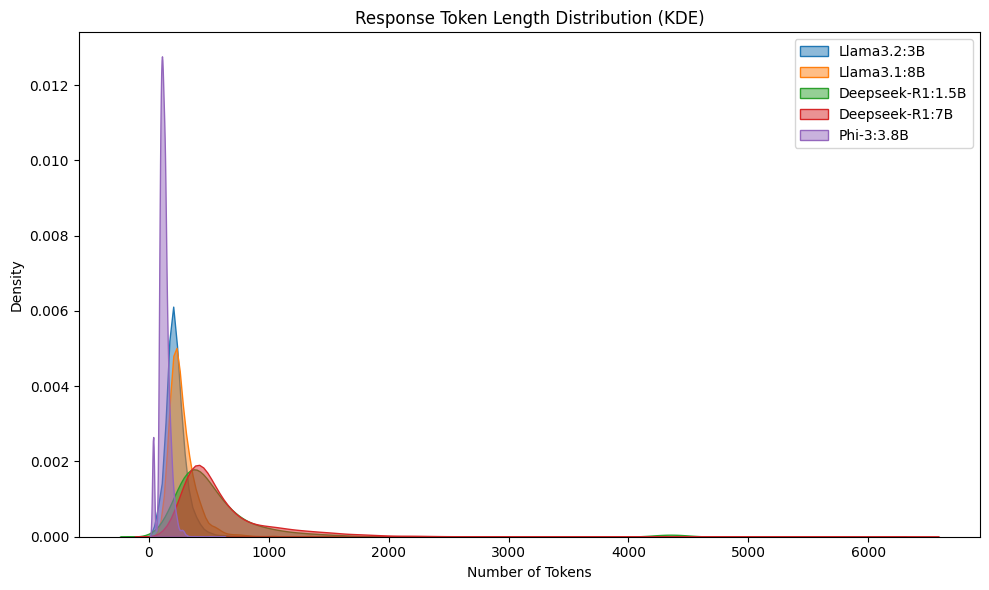

In [48]:
# Assuming gemma3_tokenizer and models_pred are defined elsewhere
# from your_tokenizer_library import gemma3_tokenizer
# from your_model_predictions import models_pred

# Create a figure and axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Loop through your models' predictions
for k, v in models_pred.items():
    # Get the DataFrame with predictions
    df = models_pred[k]['predictions_df']
    

    # Plot KDE on the axes
    sns.kdeplot(
        data=df,
        x='response_token_len',
        label=k,
        ax=ax1,
        fill=True,  # Use fill to shade the area under the KDE curve
        alpha=0.5
    )

# Configure the axes
ax1.set_xlabel("Number of Tokens")
ax1.set_ylabel("Density")

# Add a legend
ax1.legend(loc='upper right')

# Set the title and adjust the layout
plt.title("Response Token Length Distribution (KDE)")
plt.tight_layout()
plt.show()


ValueError: too many values to unpack (expected 2)

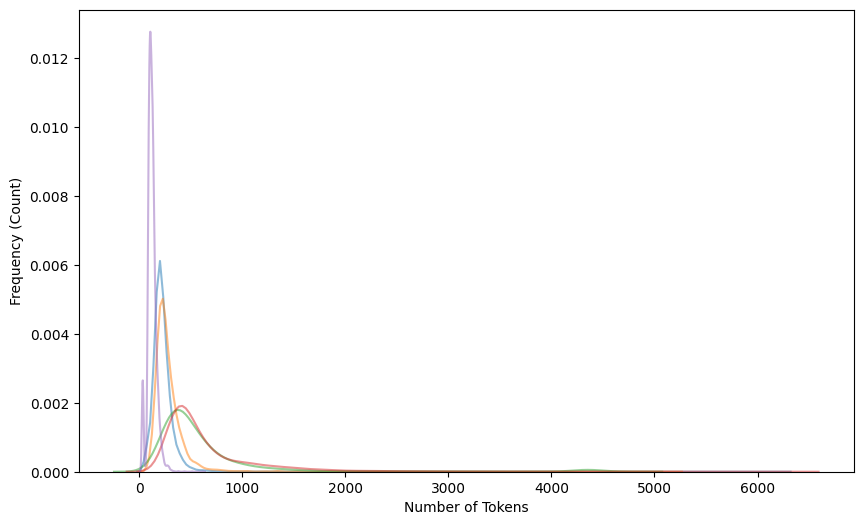

In [49]:
fig, ax1 = plt.subplots(figsize=(10, 6))

for k, v in models_pred.items():
    df = models_pred[k]['predictions_df']
    
    # Plot histogram on left y-axis
    sns.kdeplot(
        df['response_token_len'],
        label=f'{k}',
        alpha=0.5,
        ax=ax1
    )

# Configure left y-axis (histogram)
ax1.set_xlabel("Number of Tokens")
ax1.set_ylabel("Frequency (Count)")
ax1.set_xlim("3000")
# Handle legends
lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc='upper right')

plt.title("Response tokens length Distribution")
plt.tight_layout()
plt.show()


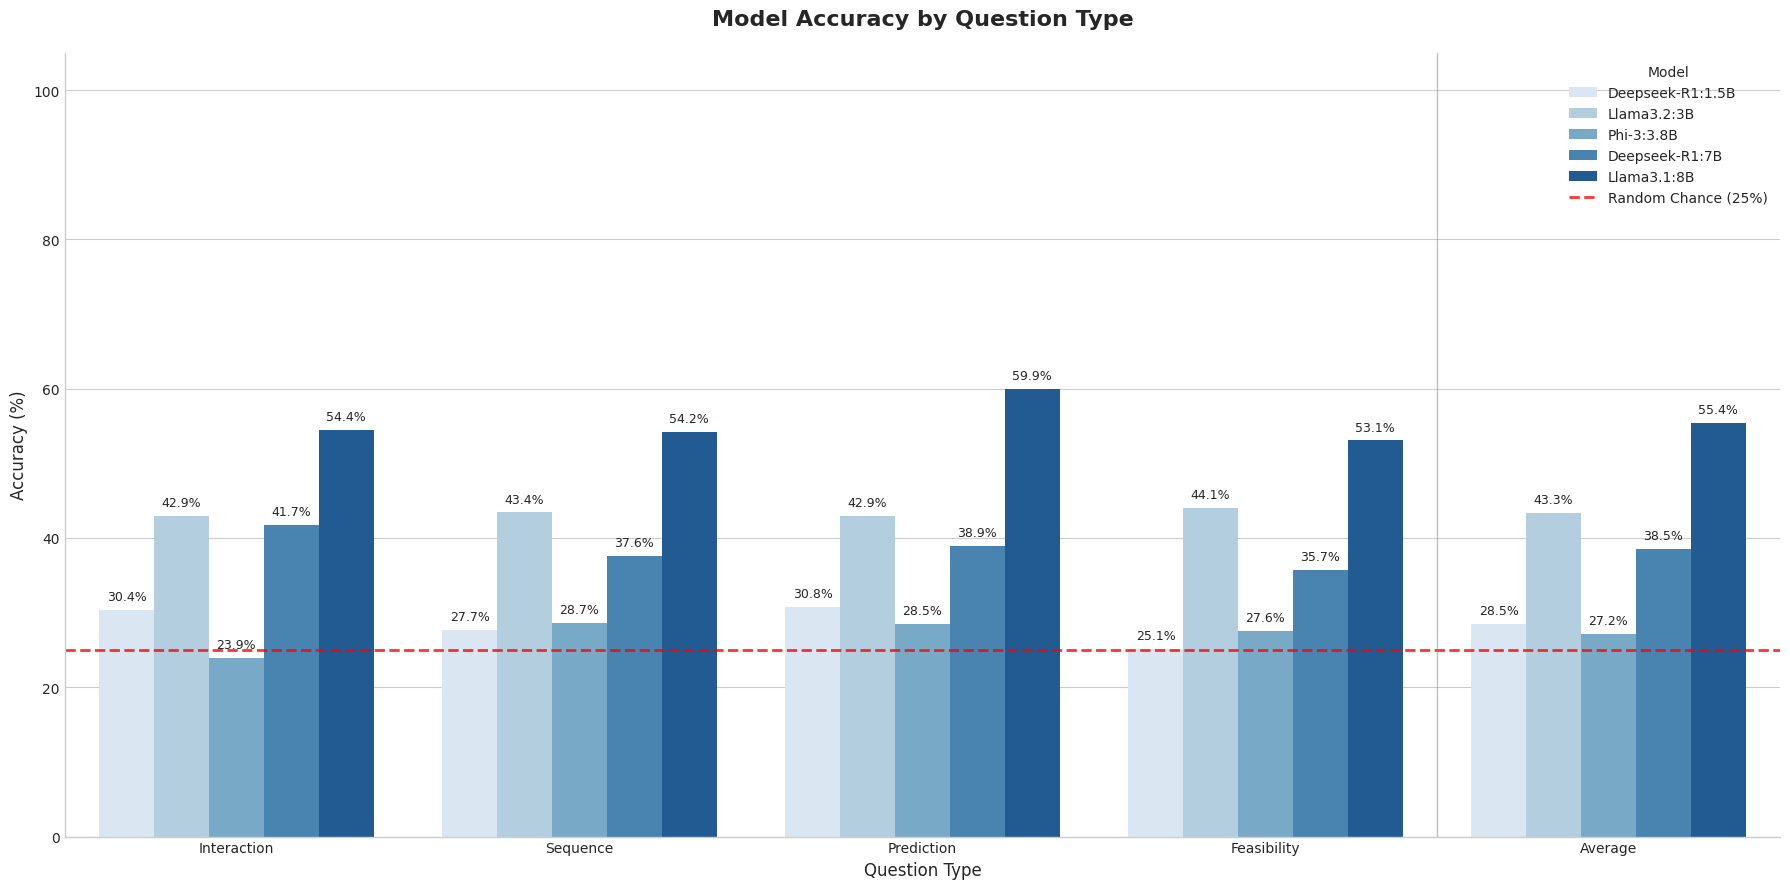

/tmp/ipykernel_1384549/2759600322.py:79: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  summary_table = df.pivot_table(values='Accuracy', index='Model',


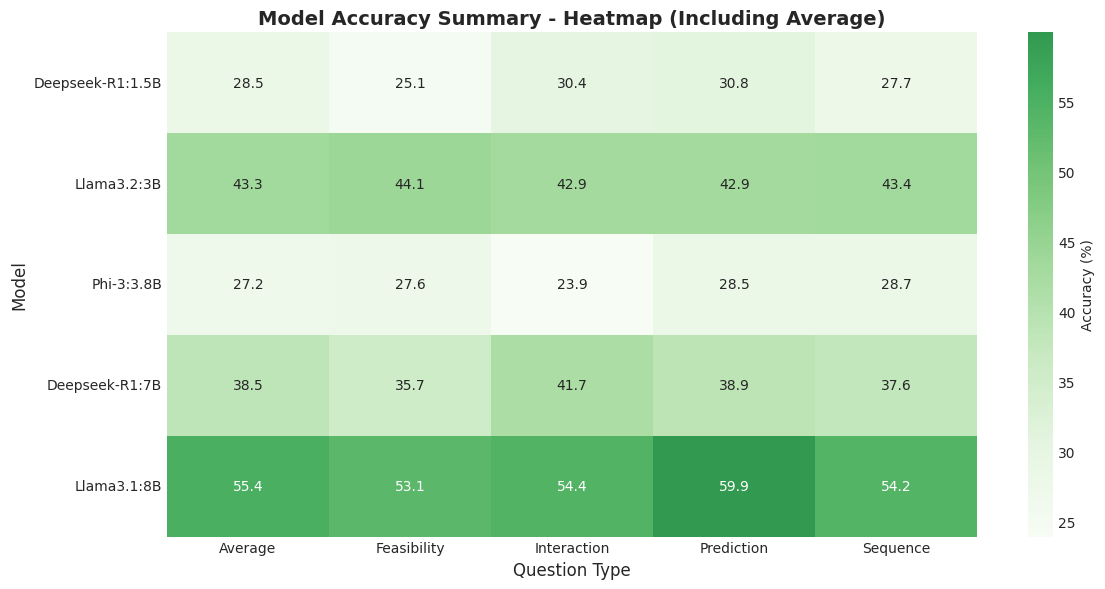

In [50]:
# Extract accuracy data with model size for ordering
data = []
model_sizes = {}
for model_key, model_data in models_pred.items():
    if isinstance(model_data, dict) and 'accuracy' in model_data:
        model_sizes[model_key] = model_data['size']
        for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility']:
            if question_type in model_data['accuracy']:
                data.append({
                    'Model': model_key,
                    'Question_Type': question_type,
                    'Accuracy': model_data['accuracy'][question_type] * 100, # Convert to percentage
                    'Model_Size': model_data['size']
                })

# Calculate average accuracy for each model across all question types
average_data = []
for model_key, model_data in models_pred.items():
    if isinstance(model_data, dict) and 'accuracy' in model_data:
        accuracies = []
        for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility']:
            if question_type in model_data['accuracy']:
                accuracies.append(model_data['accuracy'][question_type] * 100)
        if accuracies:
            average_data.append({
                'Model': model_key,
                'Question_Type': 'Average',
                'Accuracy': sum(accuracies) / len(accuracies),
                'Model_Size': model_data['size']
            })

# Combine original data with average data
all_data = data + average_data
df = pd.DataFrame(all_data)

# Sort models by size for consistent ordering
sorted_models = sorted(model_sizes.keys(), key=lambda x: model_sizes[x])
df['Model'] = pd.Categorical(df['Model'], categories=sorted_models, ordered=True)

# 1. Grouped bar plot with Average
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(18,9))
sns.barplot(data=df, x='Question_Type', y='Accuracy', hue='Model',
            palette=sns.color_palette('Blues', n_colors=len(sorted_models)), ax=ax, 
            order=['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average'])

# Add random chance baseline (25%)
ax.axhline(y=25, color='red', linestyle='--', linewidth=2, alpha=0.8, label='Random Chance (25%)')

# Add value annotations on bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9,
                    xytext=(0, 5), textcoords='offset points')

# Add a vertical separator line before Average
ax.axvline(x=3.5, color='gray', linestyle='-', linewidth=1, alpha=0.5)

# Styling
ax.set_title('Model Accuracy by Question Type', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Question Type', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 105)
ax.tick_params(axis='x', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Update legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, title='Model', loc='upper right')

plt.tight_layout()
plt.savefig('model_accuracy.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

# 2. Summary heatmap with coolwarm colormap (including average)
summary_table = df.pivot_table(values='Accuracy', index='Model',
                              columns='Question_Type', aggfunc='mean')
plt.figure(figsize=(12, 6))
sns.heatmap(summary_table, annot=True, cmap='Greens', center=50,
            fmt='.1f', cbar_kws={'label': 'Accuracy (%)'})
plt.title('Model Accuracy Summary - Heatmap (Including Average)', fontsize=14, fontweight='bold')
plt.xlabel('Question Type', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.tight_layout()
plt.savefig('model_accuracy_heatmap_with_average.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

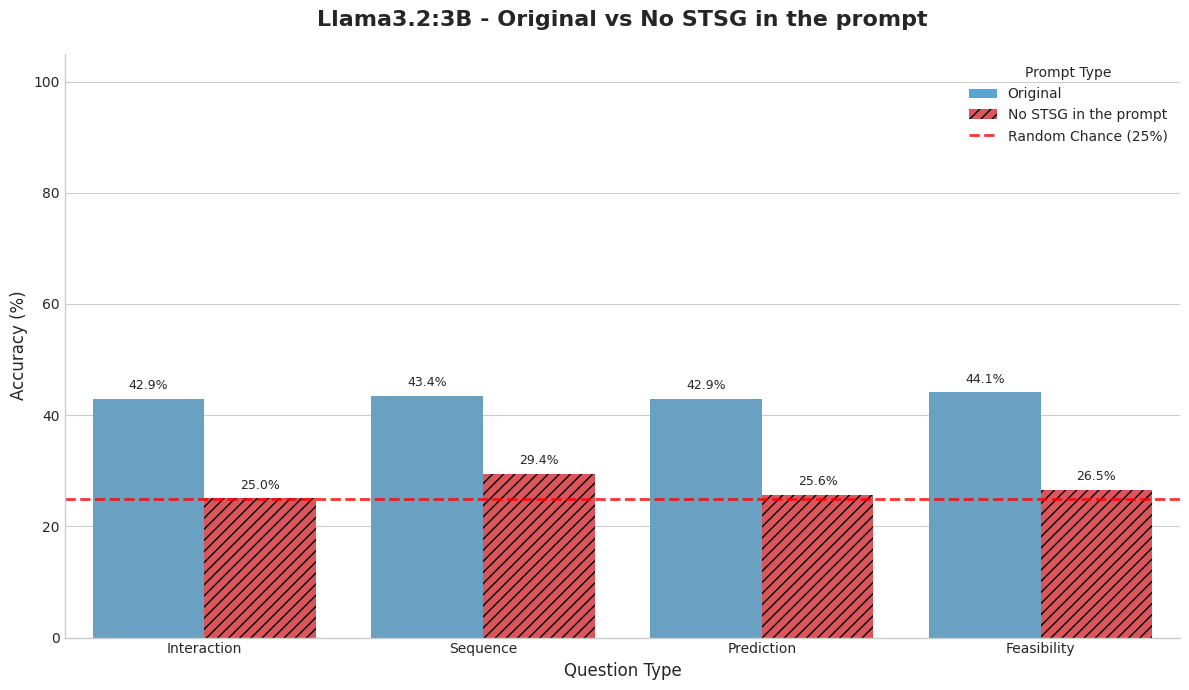


Llama3.2:3B Prompt Comparison Summary:
Prompt_Type    No STSG in the prompt  Original
Question_Type                                 
Feasibility                    26.53     44.08
Interaction                    25.02     42.91
Prediction                     25.64     42.95
Sequence                       29.45     43.42

Overall Averages:
Original: 43.34%
No STSG in the prompt: 26.66%


In [51]:
# Assuming you have your original models_pred data and the new bias_check_info
# Extract data for Llama3.2 models only
llama_data = []

# Get original Llama3.2:3B results
original_key = "Llama3.2:3B"
if original_key in models_pred and isinstance(models_pred[original_key], dict) and 'accuracy' in models_pred[original_key]:
    for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility']:
        if question_type in models_pred[original_key]['accuracy']:
            llama_data.append({
                'Model': 'Llama3.2:3B (Original)',
                'Question_Type': question_type,
                'Accuracy': models_pred[original_key]['accuracy'][question_type] * 100,
                'Model_Size': models_pred[original_key]['size'],
                'Prompt_Type': 'Original'
            })

# Get new prompt results
new_key = "Llama3.2:3B"
if new_key in bias_check_info and 'accuracy' in bias_check_info[new_key]:
    for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility']:
        if question_type in bias_check_info[new_key]['accuracy']:
            llama_data.append({
                'Model': 'Llama3.2:3B (No STSG in the prompt)',
                'Question_Type': question_type,
                'Accuracy': bias_check_info[new_key]['accuracy'][question_type] * 100,
                'Model_Size': bias_check_info[new_key]['size'],
                'Prompt_Type': 'No STSG in the prompt'
            })

df_llama = pd.DataFrame(llama_data)

# Create comparison plot
plt.style.use("seaborn-v0_8-whitegrid")

# Single comparison bar plot
fig, ax = plt.subplots(figsize=(12, 7))

# Use Blues colormap for original, reddish for new prompt
blue_color = plt.cm.Blues(0.55)  # Extract blue from Blues colormap
red_color = "#F04046"  # Reddish color

# Create the barplot
sns.barplot(data=df_llama, x='Question_Type', y='Accuracy', hue='Prompt_Type',
            palette=[blue_color, red_color], ax=ax, 
            order=['Interaction', 'Sequence', 'Prediction', 'Feasibility'])

# Add hatching pattern to the new prompt bars
patches = ax.patches
n_categories = len(df_llama['Question_Type'].unique())
n_prompt_types = len(df_llama['Prompt_Type'].unique())

# Apply hatching to the second group of bars (new prompt)
for i, patch in enumerate(patches):
    # Check if this bar belongs to the "New Prompt" group
    if i >= n_categories:  # Second set of bars
        patch.set_hatch('///')

# Add random chance baseline (25%)
ax.axhline(y=25, color='red', linestyle='--', linewidth=2, alpha=0.8, label='Random Chance (25%)')

# Add value annotations on bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%',
                   (p.get_x() + p.get_width()/2., p.get_height()),
                   ha='center', va='bottom', fontsize=9,
                   xytext=(0, 5), textcoords='offset points')

# Styling
ax.set_title('Llama3.2:3B - Original vs No STSG in the prompt', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Question Type', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 105)
ax.tick_params(axis='x', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Update legend to include baseline and fix hatching issue
handles, labels = ax.get_legend_handles_labels()

# Create custom legend handles to fix the hatching issue
from matplotlib.patches import Patch
custom_handles = []
for i, (handle, label) in enumerate(zip(handles, labels)):
    if label == 'Original':
        # Create a solid blue patch without hatching
        custom_handles.append(Patch(facecolor=blue_color, label=label))
    elif label == 'New Prompt':
        # Create a red patch with hatching
        custom_handles.append(Patch(facecolor=red_color, hatch='///', label=label))
    else:
        # Keep original handle for baseline
        custom_handles.append(handle)

ax.legend(custom_handles, labels, title='Prompt Type', loc='upper right')

plt.tight_layout()
plt.savefig('llama32_prompt_comparison.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

# Summary table
if len(df_llama) > 0:
    print("\nLlama3.2:3B Prompt Comparison Summary:")
    print("="*50)
    
    summary_table = df_llama.pivot_table(values='Accuracy', index='Question_Type', 
                                       columns='Prompt_Type', aggfunc='mean')
    
    # Calculate differences
    if 'Original' in summary_table.columns and 'New Prompt' in summary_table.columns:
        summary_table['Difference'] = summary_table['New Prompt'] - summary_table['Original']
    
    print(summary_table.round(2))
    
    # Overall averages
    print(f"\nOverall Averages:")
    for prompt_type in df_llama['Prompt_Type'].unique():
        avg_acc = df_llama[df_llama['Prompt_Type'] == prompt_type]['Accuracy'].mean()
        print(f"{prompt_type}: {avg_acc:.2f}%")
    
    if 'Original' in summary_table.columns and 'New Prompt' in summary_table.columns:
        overall_diff = df_llama[df_llama['Prompt_Type'] == 'New Prompt']['Accuracy'].mean() - \
                      df_llama[df_llama['Prompt_Type'] == 'Original']['Accuracy'].mean()
        print(f"Overall Difference: {overall_diff:.2f}%")


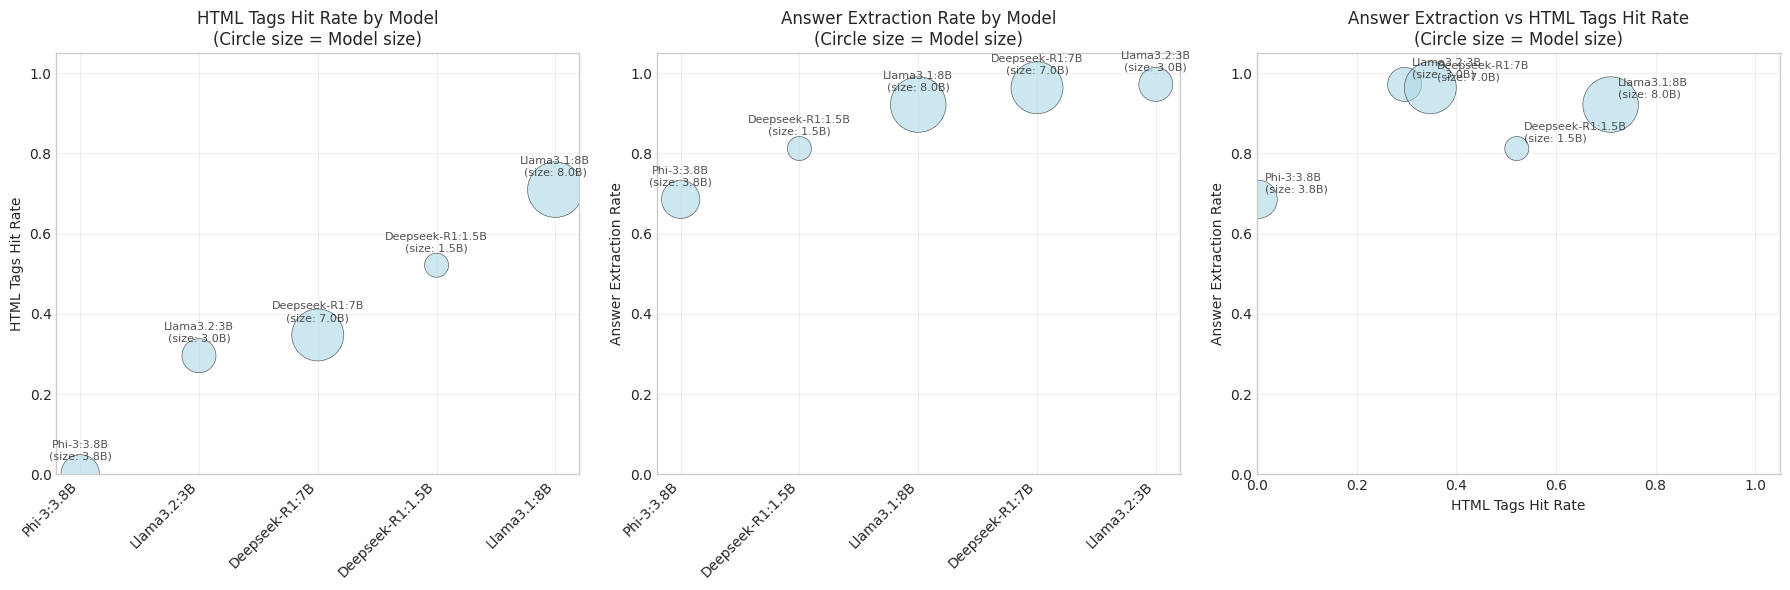

In [52]:
# Extract data from models_pred
model_names = []
model_sizes = []
html_hitrates = []
answer_hitrates = []

for model_key, model_data in models_pred.items():
    if isinstance(model_data, dict) and 'html_tags_hitrate' in model_data:
        model_names.append(model_key)
        model_sizes.append(model_data['size'])
        html_hitrates.append(model_data['html_tags_hitrate'])
        answer_hitrates.append(model_data['answer_tags_hitrate'])

# Convert to numpy arrays for easier manipulation
model_names = np.array(model_names)
model_sizes = np.array(model_sizes)
html_hitrates = np.array(html_hitrates)
answer_hitrates = np.array(answer_hitrates)

# Circle sizes proportional to model size
circle_sizes = (model_sizes / model_sizes.min()) * 300

# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: HTML Tags Hit Rate
# Sort by HTML hit rate
html_order = np.argsort(html_hitrates)
ax1.scatter(range(len(model_names)), html_hitrates[html_order], 
           s=circle_sizes[html_order], alpha=0.6, c='lightblue', 
           edgecolors='black', linewidth=0.5)

# Add annotations
for i, idx in enumerate(html_order):
    ax1.annotate(f"{model_names[idx]}\n(size: {model_sizes[idx]:.1f}B)",
                (i, html_hitrates[idx]), xytext=(0, 10),
                textcoords='offset points', fontsize=8, alpha=0.8, 
                ha='center')

ax1.set_xticks(range(len(model_names)))
ax1.set_xticklabels([model_names[i] for i in html_order], rotation=45, ha='right')
ax1.set_ylabel('HTML Tags Hit Rate')
ax1.set_title('HTML Tags Hit Rate by Model\n(Circle size = Model size)')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)

# Subplot 2: Answer Extraction Rate
# Sort by answer hit rate
answer_order = np.argsort(answer_hitrates)
ax2.scatter(range(len(model_names)), answer_hitrates[answer_order], 
           s=circle_sizes[answer_order], alpha=0.6, c='lightblue', 
           edgecolors='black', linewidth=0.5)

# Add annotations
for i, idx in enumerate(answer_order):
    ax2.annotate(f"{model_names[idx]}\n(size: {model_sizes[idx]:.1f}B)",
                (i, answer_hitrates[idx]), xytext=(0, 10),
                textcoords='offset points', fontsize=8, alpha=0.8, 
                ha='center')

ax2.set_xticks(range(len(model_names)))
ax2.set_xticklabels([model_names[i] for i in answer_order], rotation=45, ha='right')
ax2.set_ylabel('Answer Extraction Rate')
ax2.set_title('Answer Extraction Rate by Model\n(Circle size = Model size)')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.05)

# Subplot 3: Combined scatter plot
ax3.scatter(html_hitrates, answer_hitrates, s=circle_sizes, alpha=0.6,
           c='lightblue', edgecolors='black', linewidth=0.5)

# Add annotations
for i, name in enumerate(model_names):
    ax3.annotate(f"{name}\n(size: {model_sizes[i]:.1f}B)",
                (html_hitrates[i], answer_hitrates[i]), xytext=(5, 5),
                textcoords='offset points', fontsize=8, alpha=0.8)


ax3.set_xlabel('HTML Tags Hit Rate')
ax3.set_ylabel('Answer Extraction Rate')
ax3.set_title('Answer Extraction vs HTML Tags Hit Rate\n(Circle size = Model size)')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 1.05)
ax3.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('model_hitrates_analysis.svg', format='svg', bbox_inches='tight', dpi=300)
plt.show()


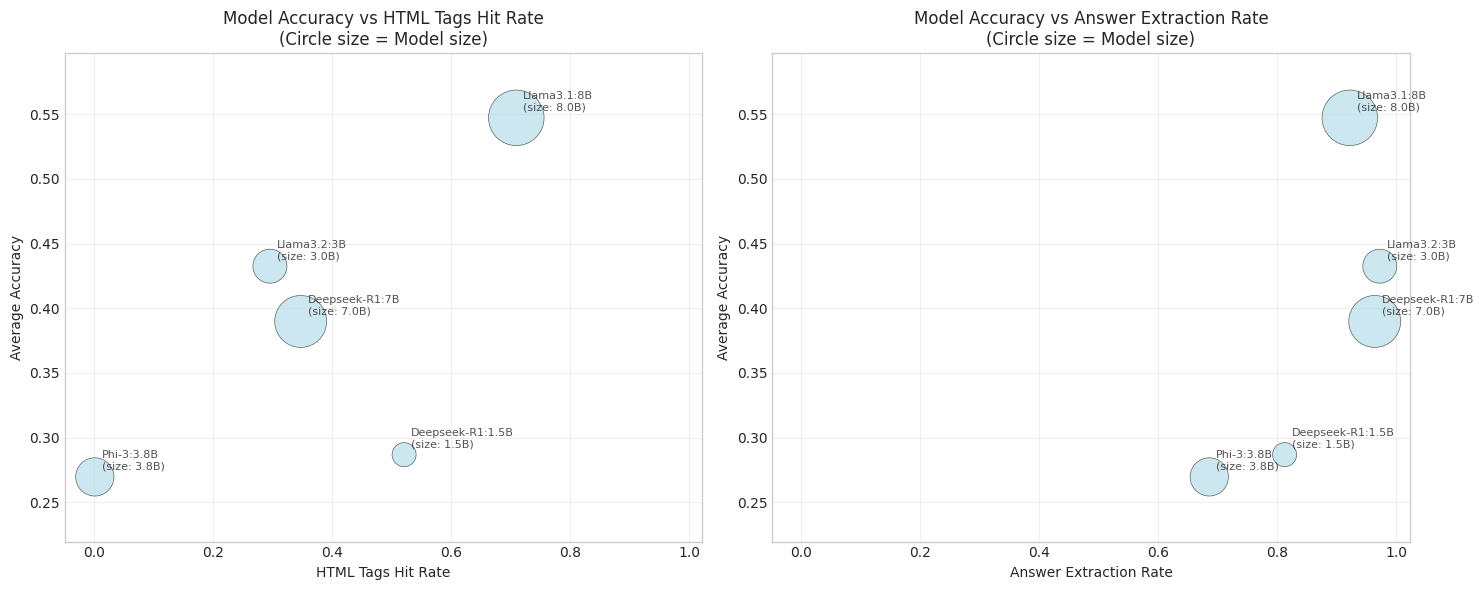

In [53]:
# Extract data from models_pred
model_names = []
model_sizes = []
html_hitrates = []
answer_hitrates = []
accuracies = []

for model_key, model_data in models_pred.items():
    if isinstance(model_data, dict) and 'html_tags_hitrate' in model_data:
        model_names.append(model_key)
        model_sizes.append(model_data['size'])
        html_hitrates.append(model_data['html_tags_hitrate'])
        answer_hitrates.append(model_data['answer_tags_hitrate'])
        # Get average accuracy
        accuracies.append(model_data['accuracy']['Average'])

# Convert to numpy arrays for easier manipulation
model_names = np.array(model_names)
model_sizes = np.array(model_sizes)
html_hitrates = np.array(html_hitrates)
answer_hitrates = np.array(answer_hitrates)
accuracies = np.array(accuracies)

# Circle sizes proportional to model size
circle_sizes = (model_sizes / model_sizes.min()) * 300

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Accuracy vs HTML Tags Hit Rate
ax1.scatter(html_hitrates, accuracies, s=circle_sizes, alpha=0.6,
           c='lightblue', edgecolors='black', linewidth=0.5)

# Add annotations
for i, name in enumerate(model_names):
    ax1.annotate(f"{name}\n(size: {model_sizes[i]:.1f}B)",
                (html_hitrates[i], accuracies[i]), xytext=(5, 5),
                textcoords='offset points', fontsize=8, alpha=0.8)

ax1.set_xlabel('HTML Tags Hit Rate')
ax1.set_ylabel('Average Accuracy')
ax1.set_title('Model Accuracy vs HTML Tags Hit Rate\n(Circle size = Model size)')
ax1.grid(True, alpha=0.3)

# Subplot 2: Accuracy vs Answer Extraction Rate
ax2.scatter(answer_hitrates, accuracies, s=circle_sizes, alpha=0.6,
           c='lightblue', edgecolors='black', linewidth=0.5)

# Add annotations
for i, name in enumerate(model_names):
    ax2.annotate(f"{name}\n(size: {model_sizes[i]:.1f}B)",
                (answer_hitrates[i], accuracies[i]), xytext=(5, 5),
                textcoords='offset points', fontsize=8, alpha=0.8)

ax2.set_xlabel('Answer Extraction Rate')
ax2.set_ylabel('Average Accuracy')
ax2.set_title('Model Accuracy vs Answer Extraction Rate\n(Circle size = Model size)')
ax2.grid(True, alpha=0.3)

# Set consistent x-axis ranges
x_min = min(min(html_hitrates), min(answer_hitrates)) - 0.05
x_max = max(max(html_hitrates), max(answer_hitrates)) + 0.05
ax1.set_xlim(x_min, x_max)
ax2.set_xlim(x_min, x_max)

# Set consistent y-axis range
y_min = min(accuracies) - 0.05
y_max = max(accuracies) + 0.05
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('model_accuracy_vs_hitrates.svg', format='svg', bbox_inches='tight', dpi=300)
plt.show()


In [54]:
models_pred.keys()


dict_keys(['Llama3.2:3B', 'Llama3.1:8B', 'Deepseek-R1:1.5B', 'Deepseek-R1:7B', 'Phi-3:3.8B'])

In [55]:
models_pred['Phi-3:3.8B']['predictions_df'].iloc[5]['answer']
predictions_df = models_pred['Phi-3:3.8B']['predictions_df']

In [56]:
predictions_df['answer']

id
Interaction_T1_13      <Reasoning>
From the given Spatio-Temporal Sce...
Interaction_T1_14      <Reasoning>
In the given Spatio-Temporal Scene...
Interaction_T1_31      <Reasoning>
The given Spatio-Temporal Scene Gr...
Interaction_T1_32      <Reasoning>
The sequence of Scene-Graphs shows...
Interaction_T1_40      <Reasoning>
The question asks about an object ...
                                             ...                        
Feasibility_T6_1453    <Reasoning>
From the given Spatio-Temporal Sce...
Feasibility_T6_1454    <Reasoning>
From the Spatio-Temporal Scene Gra...
Feasibility_T6_1455    <Reasoning>
The Scene-Graphs show that the per...
Feasibility_T6_1456    <Reasoning>
The person is repeatedly interacti...
Feasibility_T6_1468    <Reasoning>
The person is able to interact wit...
Name: answer, Length: 7098, dtype: string

In [57]:
# Check if the the template is somewhere in the answer
html_tags_pattern = r'<Final answer>\s*A:\s*\d\.\s*((?:\w+(?:\s|\/)?){,10}\.)\s*(?:</Final answer>)?'
predictions_df['html_tags_mask2']  = (
      predictions_df['answer']
      .apply(lambda x: re.search(html_tags_pattern, x, re.IGNORECASE))
      .notna()
)


print(f"Answer following the template: {predictions_df['html_tags_mask2'] .value_counts()[True]}\n")
print(f"{predictions_df['html_tags_mask2'].value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['html_tags_mask2'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")


Answer following the template: 3571

50.31% of the total

Only 3527 samples do not contain the answer in the response with the specified format


In [58]:
# Check if the the template is somewhere in the answer
#
# An example of the template expressed by the regex is: A: 1. The answer.
# where the number followed by a dot is optional
ans_regex_pattern = r'A:\s*(?:\d\.)?\s*((?:\w+(?:\s|\/)?){,10}\.?)'
predictions_df['contains_answer2'] = predictions_df['answer'].str.contains(ans_regex_pattern, case=False, regex=True, flags=re.DOTALL)


print(f"Answer following the template: {predictions_df['contains_answer2'] .value_counts()[True]}\n"
      f"{predictions_df['contains_answer2'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['contains_answer2'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")

predictions_df["pred_text2"] = ""
# Use .loc to safely modify the original DataFrame
mask = predictions_df['contains_answer2']
predictions_df.loc[mask, 'pred_text2'] = (
      predictions_df.loc[mask, 'answer']
      .apply(lambda x: re.findall(ans_regex_pattern, x)[-1])
)
predictions_df['pred_text2'] = (
      predictions_df['pred_text2']
      #.str.strip()
)

Answer following the template: 6802
95.83% of the total

Only 296 samples do not contain the answer in the response with the specified format


/tmp/ipykernel_1384549/2457202492.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df['contains_answer2'] = predictions_df['answer'].str.contains(ans_regex_pattern, case=False, regex=True, flags=re.DOTALL)


In [59]:
predictions_df[~predictions_df['contains_answer'] & predictions_df['contains_answer2']].iloc[1]['answer']


"<Reasoning>\nIn the given Spatio-Temporal Scene Graphs, we can see that initially a shoe is being held by the person. The next sequence shows the same action with an additional element of paper/notebook in front and on the side of it as well. Following this, there are actions where 'person - standing_on' floor and 'person - beneath' foot respectively which indicates someone else has entered or a change occurred that required both individuals to move from their original positions while still holding onto something (in this case shoes). Afterwards we see the person is no longer in contact with any object, suggesting they have released it. The next sequence shows them standing on floor and beneath foot again which indicates movement but not throwing an item as there's nothing mentioned about being thrown or dropped here.\n</Reasoning> \n<Final answer>\nA: None of the alternatives were correct based on given Spatio-Temporal Scene Graphs"

In [60]:
predictions_df[~predictions_df['html_tags_mask2'] & predictions_df['contains_answer2']].iloc[3]['answer']


"<Reasoning>\nThe Spatio-Temporal Scene Graphs provided do not contain any information about the person interacting with a refrigerator, door or bag. The only objects mentioned are 'laptop' and 'clothes'. Throughout all frames in these graphs, we see that there is no mention of opening anything related to those three items. However, it does show multiple instances wherein the subject (person) interacts with a laptop by holding it and being on its front side or touching clothes while also handling the laptop.\n</Reasoning> \n<Final answer>\nA: The question cannot be answered based on the provided Spatio-Temporal Scene Graphs as they do not provide information about opening any object."

<Axes: xlabel='freq', ylabel='word'>

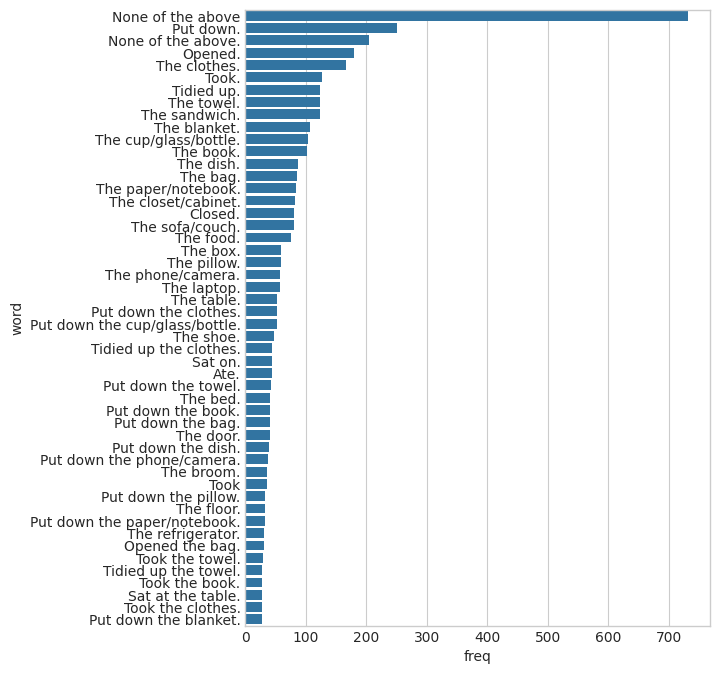

In [61]:
freq = predictions_df[predictions_df['contains_answer2']]['pred_text2'].value_counts().reset_index()
freq.columns = ['word', 'freq']
plt.figure(figsize=(6, 8))
sns.barplot(data=freq.sort_values('freq', ascending=False)[:50], x='freq', y='word')


<Axes: xlabel='freq', ylabel='word'>

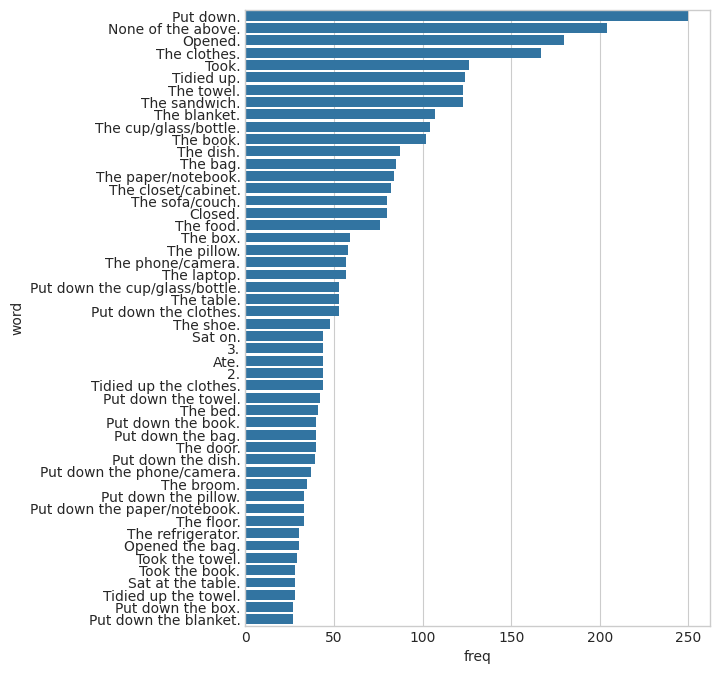

In [62]:
freq = predictions_df[predictions_df['contains_answer']]['pred_text'].value_counts().reset_index()
freq.columns = ['word', 'freq']
plt.figure(figsize=(6, 8))
sns.barplot(data=freq.sort_values('freq', ascending=False)[:50], x='freq', y='word')


In [63]:
eval_df['edit_distance'] = eval_df.apply(func=lambda row: edit_distance(row['text'], row['pred_text']), axis=1)

eval_df['edit_distance'].sort_values(ascending=True).value_counts(sort=False)


edit_distance
0     1946
2       83
3       99
4      523
5      569
6      427
7      785
8      451
9      157
10     317
11     300
12     289
13     341
14     196
15     171
16      56
17      83
18      95
19      78
20      45
21      38
22      34
23       5
24       5
25       1
26       1
28       3
Name: count, dtype: int64

In [64]:
eval_df[(eval_df['edit_distance'] > 0) & (eval_df['edit_distance'] < 3)]


,choices,num,text,pred_text,edit_distance
id,,,,,
Interaction_T1_427,"{'0': 'The towel.', '1': 'The box.', '2': 'The...",1,The box.,The bag.,2
Interaction_T1_526,"{'0': 'The book.', '1': 'The bag.', '2': 'The ...",0,The book.,The door.,2
Interaction_T1_714,"{'0': 'The door.', '1': 'The book.', '2': 'The...",1,The book.,The door.,2
Interaction_T1_1246,"{'0': 'The box.', '1': 'The broom.', '2': 'The...",0,The box.,The book.,2
Interaction_T1_2345,"{'0': 'The box.', '1': 'The book.', '2': 'The ...",3,The broom.,The book.,2
...,...,...,...,...,...
Feasibility_T5_1966,"{'0': 'The blanket.', '1': 'The pillow.', '2':...",3,The box.,The bag.,2
Feasibility_T5_2202,"{'0': 'The door.', '1': 'The book.', '2': 'The...",1,The book.,The box.,2
Feasibility_T5_2343,"{'0': 'The book.', '1': 'The clothes.', '2': '...",0,The book.,The food.,2
